<a href="https://colab.research.google.com/github/munawirmt/prediction-models/blob/main/adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADABOOSTER ALGORITHM (DT)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#load and prepare dataset
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
data.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [ ]:
#split data train data =80% and test data=20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}\n")

Training shape: (142, 13)
Testing shape: (36, 13)



create and train adaboost model

In [ ]:
#define weak learner (stump)
weak_learner = DecisionTreeClassifier(max_depth=1, random_state=42)

#initialize adaboost
# n_estimators = number of trees to build
# learning_rate = shrinks the contribution of each tree
ada_model = AdaBoostClassifier(
    estimator=weak_learner,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

#train the model
ada_model.fit(X_train, y_train)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   random_state=42)

In [ ]:
#predict on test data
y_pred = ada_model.predict(X_test)

#calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Model Performance ---")
print(f"Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- Model Performance ---
Accuracy: 0.9444

Classification Report:
              precision    recall  f1-score   support

     class_0       0.93      1.00      0.97        14
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

Confusion Matrix:
[[14  0  0]
 [ 1 13  0]
 [ 0  1  7]]


check feature importance

In [ ]:
#check which feature the model most useful
importances = pd.Series(ada_model.feature_importances_, index=data.feature_names)
top_features = importances.sort_values(ascending=False).head(5)

print("\nTop 5 Most Important Features:")
print(top_features)


Top 5 Most Important Features:
flavanoids         0.472317
alcohol            0.179625
color_intensity    0.134005
proline            0.114016
hue                0.051051
dtype: float64


In [ ]:
import pandas as pd

#which one is weak features to this model
#The weak_learner (DecisionTreeClassifier with max_depth=1) needs to be fitted independently to calculate its feature importances.
# Note: This is the feature importance of a single decision stump, not the ensemble.

# Fit the weak learner on the training data
weak_learner.fit(X_train, y_train)

weak_learner_features = pd.Series(weak_learner.feature_importances_, index=data.feature_names)
#print which is weak feature to this model
print("Weak Learner Features:")
print(weak_learner_features)

Weak Learner Features:
alcohol                         0.0
malic_acid                      0.0
ash                             0.0
alcalinity_of_ash               0.0
magnesium                       0.0
total_phenols                   0.0
flavanoids                      0.0
nonflavanoid_phenols            0.0
proanthocyanins                 0.0
color_intensity                 1.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                         0.0
dtype: float64


--- Weak Learner Frequency vs Ensemble Importance ---
                              Times Picked (Weak Learners)  \
flavanoids                                            24.0   
alcohol                                               10.0   
color_intensity                                        7.0   
proline                                                5.0   
hue                                                    2.0   
od280/od315_of_diluted_wines                           2.0   
alcalinity_of_ash                                      0.0   
ash                                                    0.0   
magnesium                                              0.0   
nonflavanoid_phenols                                   0.0   
malic_acid                                             0.0   
proanthocyanins                                        0.0   
total_phenols                                          0.0   

                              Ensemble Importance Score  
flavanoids         

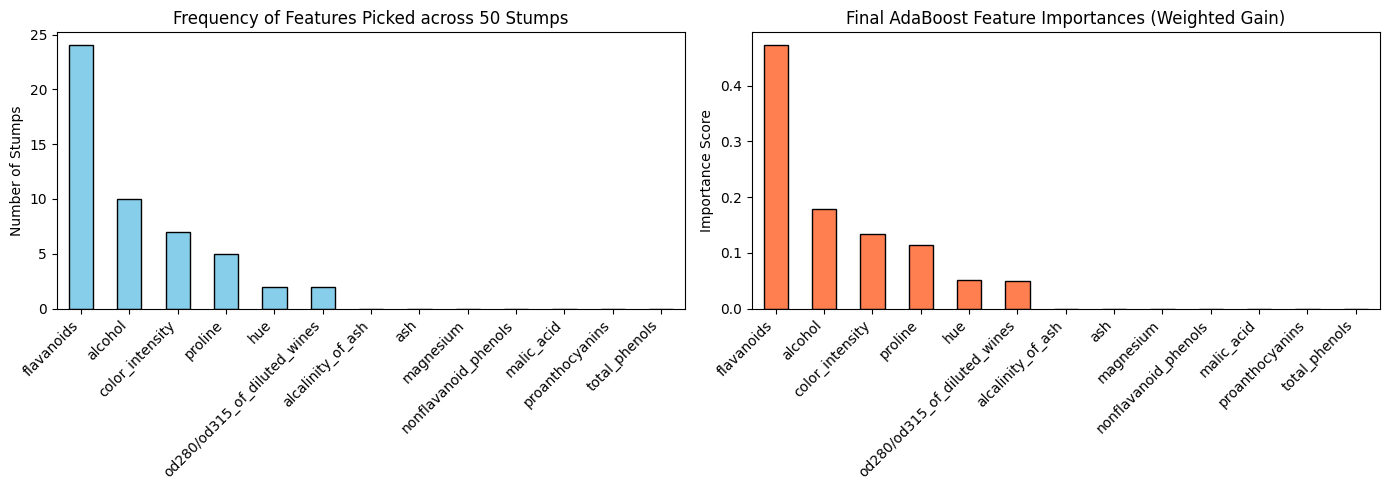

In [ ]:
#compare the weak learner features with the ensemble top features
stump_features = [
    data.feature_names[tree.tree_.feature[0]]
    for tree in ada_model.estimators_
]

# Count how many times each feature was picked by weak learners
stump_counts = pd.Series(stump_features).value_counts()

# Get final AdaBoost weighted feature importances
ensemble_importances = pd.Series(ada_model.feature_importances_, index=data.feature_names)

# Combine into a single comparison DataFrame
comparison_df = pd.DataFrame({
    'Times Picked (Weak Learners)': stump_counts,
    'Ensemble Importance Score': ensemble_importances
}).fillna(0).sort_values(by='Ensemble Importance Score', ascending=False)

print("--- Weak Learner Frequency vs Ensemble Importance ---")
print(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Weak Learner Selection Counts
comparison_df['Times Picked (Weak Learners)'].plot(
    kind='bar', ax=axes[0], color='skyblue', edgecolor='black'
)
axes[0].set_title("Frequency of Features Picked across 50 Stumps")
axes[0].set_ylabel("Number of Stumps")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Plot 2: Final Ensemble Feature Importances
comparison_df['Ensemble Importance Score'].plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title("Final AdaBoost Feature Importances (Weighted Gain)")
axes[1].set_ylabel("Importance Score")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()